# DQN Epsilon Decay Ablation Study

This notebook tests how different epsilon decay rates affect DQN performance on LunarLander. We'll train multiple agents with varying epsilon_decay values and compare their learning curves and final performance.

**Baseline:** epsilon_decay = 0.995

## 1. Setup and Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

# Import from vanilla DQN module

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from core.vanilla_dqn_lunar_lander import VanillaDQN, device, save_results, save_model, save_plot, set_global_seed

from gymnasium import make

Using device: cuda


## 2. Training Function (Adapted from Vanilla)

In [2]:
def train_dqn(num_episodes=100, batch_size=32, update_frequency=4, target_update_frequency=100,
              epsilon_decay=0.995, seed=None, verbose=True):
    """Train the DQN agent on LunarLander"""

    # ======== Reproducible epsilon-decay training setup ========
    # A provided seed controls Python, NumPy, PyTorch, and the Gymnasium action sampler.
    set_global_seed(seed)
    # ======== End reproducible epsilon-decay training setup ========

    # Create environment
    env = make('LunarLander-v3')
    if seed is not None:
        env.action_space.seed(seed)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Create agent with specified epsilon_decay
    agent = VanillaDQN(state_dim, action_dim, epsilon_decay=epsilon_decay)

    # Training loop
    episode_rewards = []
    episode_losses = []
    epsilon_history = []

    for episode in range(num_episodes):
        # ======== Seeded episode reset ========
        if seed is None:
            state, _ = env.reset()
        else:
            state, _ = env.reset(seed=seed + episode)
        # ======== End seeded episode reset ========

        episode_reward = 0
        episode_loss = []
        done = False
        step = 0

        while not done:
            # Select and execute action
            action = agent.select_action(state, training=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Store transition
            agent.store_transition(state, action, reward, next_state, done)

            # Update network
            if step % update_frequency == 0:
                loss = agent.update(batch_size)
                if loss is not None:
                    episode_loss.append(loss)

            episode_reward += reward
            state = next_state
            step += 1

        # Update target network
        if (episode + 1) % target_update_frequency == 0:
            agent.update_target_network()

        # Decay epsilon
        agent.decay_epsilon()

        # Record metrics
        episode_rewards.append(episode_reward)
        epsilon_history.append(agent.epsilon)
        if episode_loss:
            episode_losses.append(np.mean(episode_loss))

        # Print progress
        if verbose and (episode + 1) % 25 == 0:
            avg_reward = np.mean(episode_rewards[-25:])
            print(f"  Episode {episode + 1}/{num_episodes} | Avg Reward (last 25): {avg_reward:.2f} | Epsilon: {agent.epsilon:.4f}")

    env.close()

    return agent, episode_rewards, episode_losses, epsilon_history


## 3. Ablation Study: Test Multiple Epsilon Decay Values

In [3]:
# Epsilon decay values to test
epsilon_decay_values = [0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90, 0.95, 0.99, 0.995, 0.999]
num_episodes = 500

# ======== Multi-seed experiment setup ========
# Use the same five seeds for every epsilon decay value so the comparison is fairer.
seeds = [0, 1, 2, 3, 4]
# ======== End multi-seed experiment setup ========

# Store results
results = {}
run_records = []

print("="*70)
print(f"DQN Epsilon Decay Ablation Study")
print(f"Testing {len(epsilon_decay_values)} epsilon_decay values x {len(seeds)} seeds = {len(epsilon_decay_values) * len(seeds)} training runs")
print("="*70)

for epsilon_decay in epsilon_decay_values:
    results[epsilon_decay] = {'runs': []}

    for seed in seeds:
        # ======== Multi-seed epsilon-decay run ========
        # Each epsilon decay value is trained with the same seed set to reduce lucky-run bias.
        variant_name = f'{epsilon_decay}_seed_{seed}'
        print("\n" + "="*70)
        print(f"Training with epsilon_decay = {epsilon_decay}, seed = {seed}")
        print("="*70)

        agent, rewards, losses, epsilon_history = train_dqn(
            num_episodes=num_episodes,
            epsilon_decay=epsilon_decay,
            seed=seed,
        )

        hyperparameters = {
            'learning_rate': 1e-3,
            'num_layers': 2,
            'hidden_dim': 128,
            'epsilon_decay': epsilon_decay,
            'batch_size': 32,
            'num_episodes': num_episodes,
            'seed': seed,
            'seeds': seeds,
        }

        # Results saved to: results/ablations/epsilon_decay/{epsilon_decay}_seed_{seed}/
        save_results(agent, rewards, losses, hyperparameters,
                     experiment_name='epsilon_decay', variant_name=variant_name)
        save_model(agent, experiment_name='epsilon_decay', variant_name=variant_name)
        save_plot(rewards, losses, experiment_name='epsilon_decay', variant_name=variant_name)

        run_result = {
            'agent': agent,
            'rewards': rewards,
            'losses': losses,
            'epsilon_history': epsilon_history,
            'seed': seed,
            'final_avg_reward': float(np.mean(rewards[-25:])),
            'mean_reward': float(np.mean(rewards)),
            'best_reward': float(max(rewards)),
            'initial_avg_reward': float(np.mean(rewards[:25])),
        }
        results[epsilon_decay]['runs'].append(run_result)
        run_records.append({'epsilon_decay': epsilon_decay, **run_result})
        # ======== End multi-seed epsilon-decay run ========

    # ======== Aggregate epsilon-decay results across seeds ========
    runs = results[epsilon_decay]['runs']
    results[epsilon_decay]['rewards'] = np.mean([run['rewards'] for run in runs], axis=0)
    results[epsilon_decay]['epsilon_history'] = np.mean([run['epsilon_history'] for run in runs], axis=0)
    results[epsilon_decay]['final_avg_reward'] = float(np.mean([run['final_avg_reward'] for run in runs]))
    results[epsilon_decay]['final_avg_reward_std'] = float(np.std([run['final_avg_reward'] for run in runs]))
    results[epsilon_decay]['mean_reward'] = float(np.mean([run['mean_reward'] for run in runs]))
    results[epsilon_decay]['mean_reward_std'] = float(np.std([run['mean_reward'] for run in runs]))
    results[epsilon_decay]['best_reward'] = float(np.mean([run['best_reward'] for run in runs]))
    results[epsilon_decay]['best_reward_std'] = float(np.std([run['best_reward'] for run in runs]))
    results[epsilon_decay]['initial_avg_reward'] = float(np.mean([run['initial_avg_reward'] for run in runs]))
    results[epsilon_decay]['initial_avg_reward_std'] = float(np.std([run['initial_avg_reward'] for run in runs]))
    # ======== End aggregate epsilon-decay results across seeds ========

print("\n" + "="*70)
print("Training Complete!")
print("="*70)


DQN Epsilon Decay Ablation Study
Testing 14 epsilon_decay values x 5 seeds = 70 training runs

Training with epsilon_decay = 0.45, seed = 0
  Episode 25/500 | Avg Reward (last 25): -203.03 | Epsilon: 0.0100
  Episode 50/500 | Avg Reward (last 25): -259.36 | Epsilon: 0.0100
  Episode 75/500 | Avg Reward (last 25): -220.20 | Epsilon: 0.0100
  Episode 100/500 | Avg Reward (last 25): -252.38 | Epsilon: 0.0100
  Episode 125/500 | Avg Reward (last 25): -240.41 | Epsilon: 0.0100
  Episode 150/500 | Avg Reward (last 25): -206.14 | Epsilon: 0.0100
  Episode 175/500 | Avg Reward (last 25): -193.65 | Epsilon: 0.0100
  Episode 200/500 | Avg Reward (last 25): -459.08 | Epsilon: 0.0100
  Episode 225/500 | Avg Reward (last 25): -262.44 | Epsilon: 0.0100
  Episode 250/500 | Avg Reward (last 25): -132.32 | Epsilon: 0.0100
  Episode 275/500 | Avg Reward (last 25): -169.80 | Epsilon: 0.0100
  Episode 300/500 | Avg Reward (last 25): -161.26 | Epsilon: 0.0100
  Episode 325/500 | Avg Reward (last 25): -159.

## 4. Summary Statistics

In [4]:
# Calculate summary statistics
summary_data = []

for eps_decay in epsilon_decay_values:
    # ======== Multi-seed summary statistics ========
    summary_data.append({
        'Epsilon Decay': eps_decay,
        'Best Reward Mean': results[eps_decay]['best_reward'],
        'Best Reward Std': results[eps_decay]['best_reward_std'],
        'Final Avg Mean (last 25)': results[eps_decay]['final_avg_reward'],
        'Final Avg Std (last 25)': results[eps_decay]['final_avg_reward_std'],
        'Mean Reward': results[eps_decay]['mean_reward'],
        'Mean Reward Std': results[eps_decay]['mean_reward_std'],
        'Initial Avg Mean (first 25)': results[eps_decay]['initial_avg_reward'],
        'Initial Avg Std (first 25)': results[eps_decay]['initial_avg_reward_std'],
    })
    # ======== End multi-seed summary statistics ========

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("SUMMARY ACROSS SEEDS")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)



SUMMARY ACROSS SEEDS
 Epsilon Decay  Best Reward Mean  Best Reward Std  Final Avg Mean (last 25)  Final Avg Std (last 25)  Mean Reward  Mean Reward Std  Initial Avg Mean (first 25)  Initial Avg Std (first 25)
         0.450        283.930197        16.269832                -48.115152                27.744700  -158.979638        24.064015                  -234.872100                   58.792554
         0.500        275.676791        10.035795                -32.420343                67.475672  -146.274662        40.147224                  -273.567845                   77.447888
         0.550        254.079378        42.577074                -38.113166                25.102308  -137.527472        20.794766                  -254.304018                   46.073466
         0.600        278.458579        20.234910                  7.892223                43.865999  -138.274663        41.647632                  -334.760616                   59.294541
         0.650        282.409103      

**Stability of the model**

While a purely statistical glance at the summary table shows that epsilon_decay = 0.999 yields the lowest standard deviation, this reflects an illusion of stability. Because a decay rate of 0.999 keeps exploration excessively high throughout all 500 episodes, the agent fails to converge on a viable strategy. Its low variance merely indicates that it is consistently failing and receiving uniform negative penalties, resulting in a flat, mediocre learning trajectory. True learning instability is instead exemplified by 0.70, which exhibits wild, unpredictable reward swings without consolidating a clear policy.

## 5. Visualization: Individual Training Curves

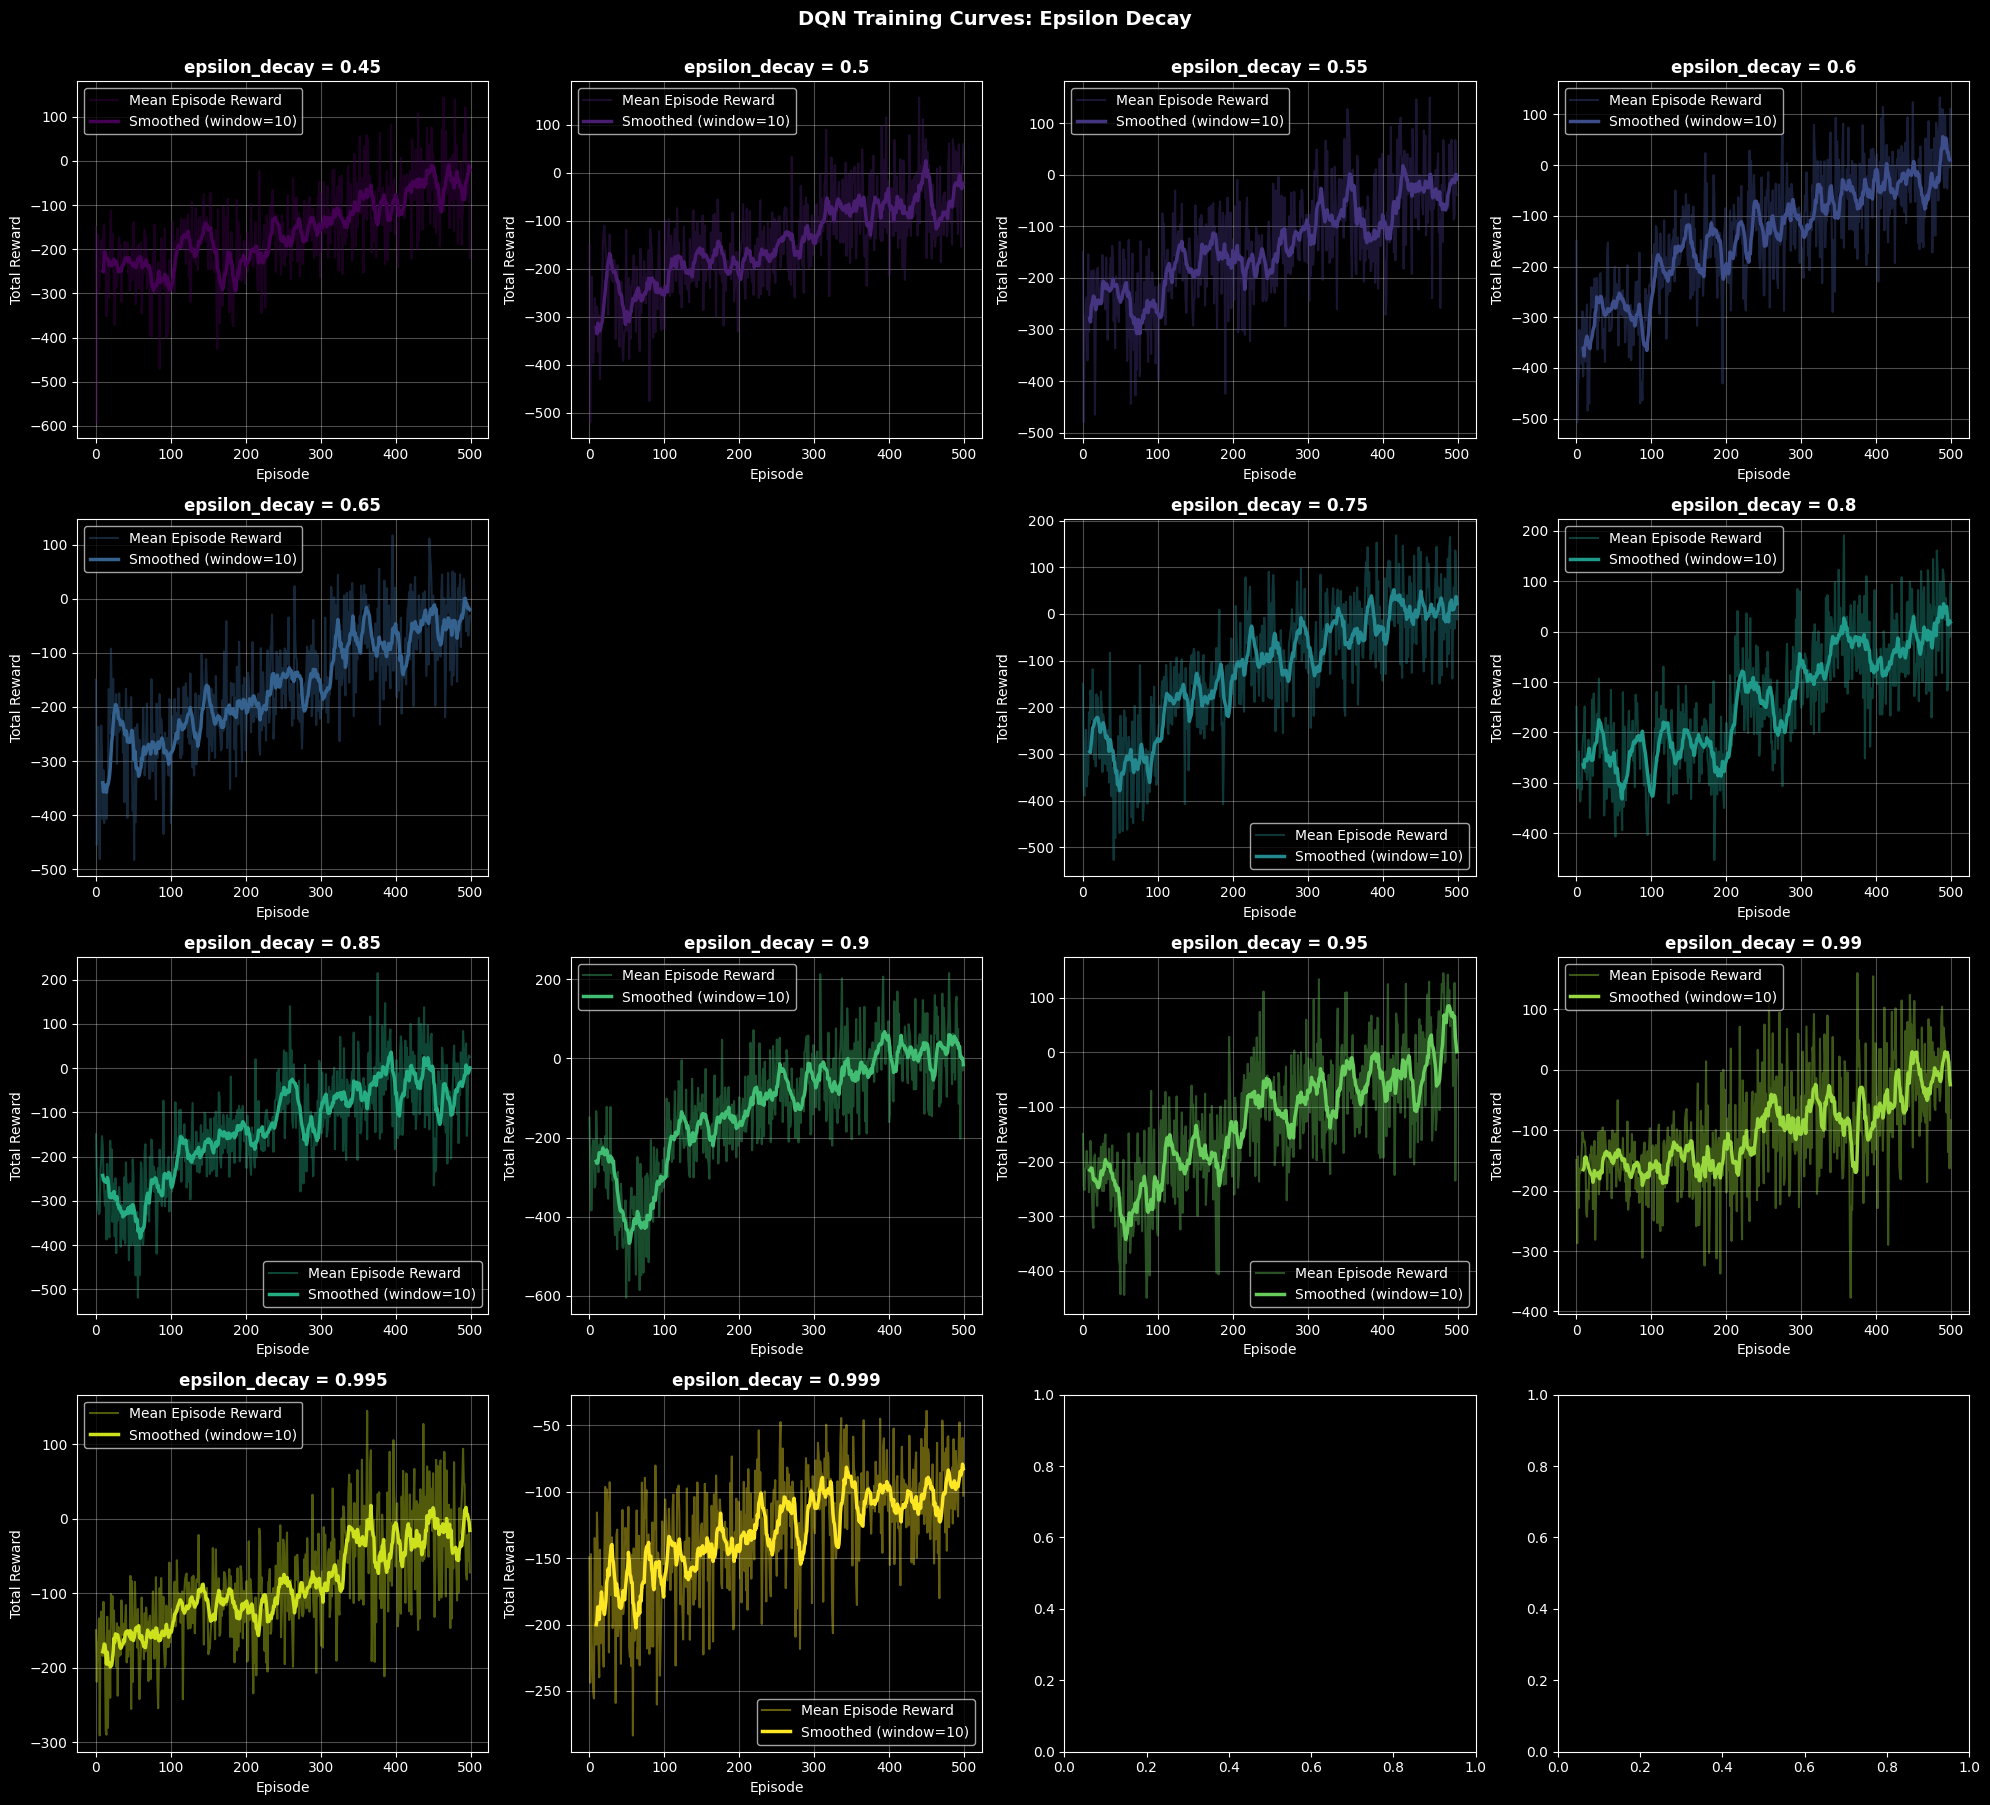

In [5]:
## 5. Visualization: Individual Training Curves
# Plot mean training curves across seeds for each epsilon_decay
# ======== Mean-curve visualization across seeds ========
num_values = len(epsilon_decay_values)
cols = 4  # 4 columns
rows = (num_values + cols - 1) // cols  # Calculate rows needed (ceiling division)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4.5))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

colors = plt.cm.viridis(np.linspace(0, 1, num_values))

for idx, eps_decay in enumerate(epsilon_decay_values):
    ax = axes[idx]
    rewards = results[eps_decay]['rewards']

    # Raw rewards
    ax.plot(rewards, alpha=0.4, color=colors[idx], label='Mean Episode Reward')

    # Smoothed rewards (window=10)
    window = 10
    smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')
    ax.plot(range(window - 1, len(rewards)), smoothed, color=colors[idx],
            linewidth=2.5, label=f'Smoothed (window={window})')

    ax.set_title(f'epsilon_decay = {eps_decay}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.grid(True, alpha=0.3)
    ax.legend()

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle('DQN Training Curves: Epsilon Decay', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()
# ======== End mean-curve visualization across seeds ========

**Analysis of Training Curves Across Epsilon Decay Values**

The strongest-performing epsilon decay values are 0.75, 0.80, 0.90, 0.95, 0.99, and 0.995. These configurations either achieve strong final rewards or maintain comparatively favorable average rewards throughout training. In contrast, 0.45, 0.50, 0.65, and 0.999 demonstrate weaker learning performance and lower rewards.

The results suggest that epsilon decay rates between approximately 0.75 and 0.95 provide the most favorable balance between exploration and exploitation. These settings exhibit the strongest upward learning trends and generally achieve the highest final rewards. Lower decay rates (0.45–0.60) show gradual improvement but appear less efficient than the best-performing configurations. Conversely, extremely high decay rates, particularly ε = 0.999, maintain exploration for too long and exhibit limited convergence within 500 episodes.

The continued positive slopes observed in several learning curves indicate that training had not fully converged by the end of the experiment. Consequently, extending training beyond 500 episodes could yield further improvements, particularly for epsilon decay values between 0.65 and 0.95, which continue to demonstrate upward learning trajectories during the final stages of training.

## 6. Visualization: Comparison of Final Performance

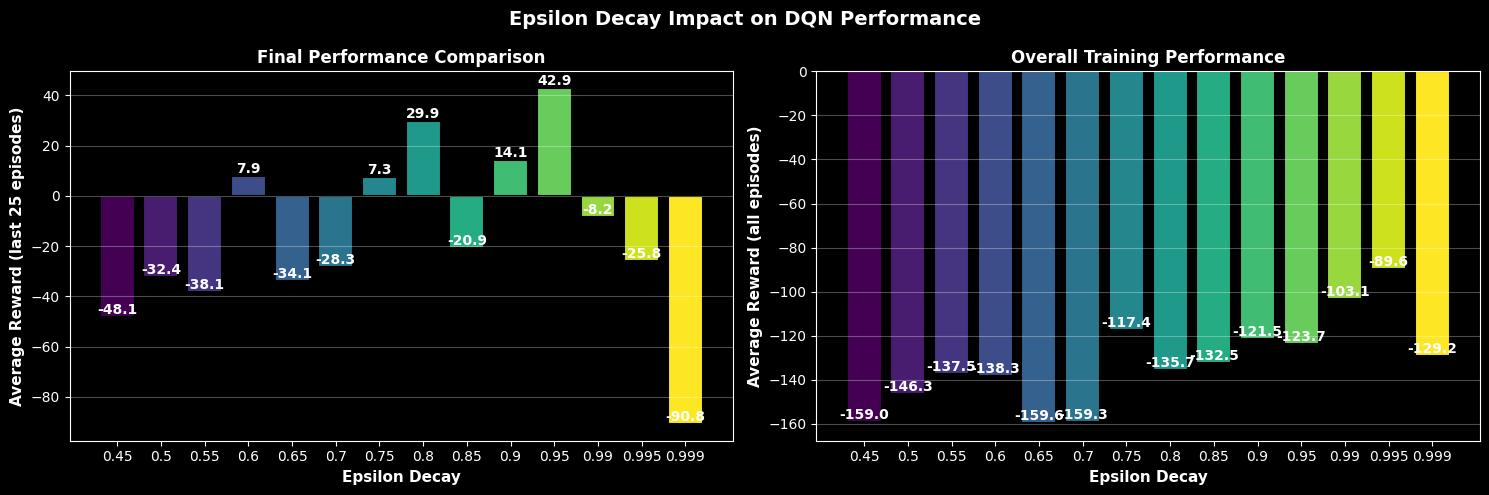

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Final Average Reward (last 25 episodes)
# ======== Plot aggregated performance across seeds ========
final_avgs = [results[eps]['final_avg_reward'] for eps in epsilon_decay_values]
colors_bar = plt.cm.viridis(np.linspace(0, 1, len(epsilon_decay_values)))

bars1 = axes[0].bar(range(len(epsilon_decay_values)), final_avgs, color=colors_bar, edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(epsilon_decay_values)))
axes[0].set_xticklabels([f'{eps}' for eps in epsilon_decay_values])
axes[0].set_xlabel('Epsilon Decay', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Average Reward (last 25 episodes)', fontsize=11, fontweight='bold')
axes[0].set_title('Final Performance Comparison', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars1, final_avgs):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Mean Reward (entire training)
mean_rewards = [results[eps]['mean_reward'] for eps in epsilon_decay_values]

bars2 = axes[1].bar(range(len(epsilon_decay_values)), mean_rewards, color=colors_bar, edgecolor='black', linewidth=1.5)
axes[1].set_xticks(range(len(epsilon_decay_values)))
axes[1].set_xticklabels([f'{eps}' for eps in epsilon_decay_values])
axes[1].set_xlabel('Epsilon Decay', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Average Reward (all episodes)', fontsize=11, fontweight='bold')
axes[1].set_title('Overall Training Performance', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars2, mean_rewards):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Epsilon Decay Impact on DQN Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# ======== End plot aggregated performance across seeds ========

**Epsilon Decay Impact: Final vs. Overall Training Performance**
The left graph shows that ε-decay values of 0.95, 0.80, and 0.90 achieve the strongest final performance, whereas 0.999, 0.45, and 0.55 perform worst during the last 25 episodes. In contrast, the overall training performance metric (right graph) identifies 0.995, 0.99, and 0.75 as the strongest performers, while 0.70, 0.65, and 0.45 exhibit the lowest average rewards. Notably, ε = 0.45 performs poorly under both evaluation criteria.

The results indicate that the optimal epsilon decay depends on the performance metric considered. Values such as 0.95, 0.80, and 0.90 maximize end-of-training performance, whereas 0.995 and 0.99 achieve stronger average performance across the entire training process. This suggests a trade-off between maximizing final policy quality and maintaining consistent performance throughout training.

Interestingly, ε = 0.70 demonstrates relatively poor overall performance but achieves a considerably stronger final reward. This pattern suggests that the agent continued learning throughout training and experienced substantial improvement during later episodes.

Similarly, ε = 0.995 attains the highest average reward despite relatively weak final performance. This outcome suggests that the agent maintained more consistent performance across training, whereas configurations with superior final rewards likely incurred larger losses during earlier exploratory phases.

## 7. Visualization: Exploration Decay Over Time

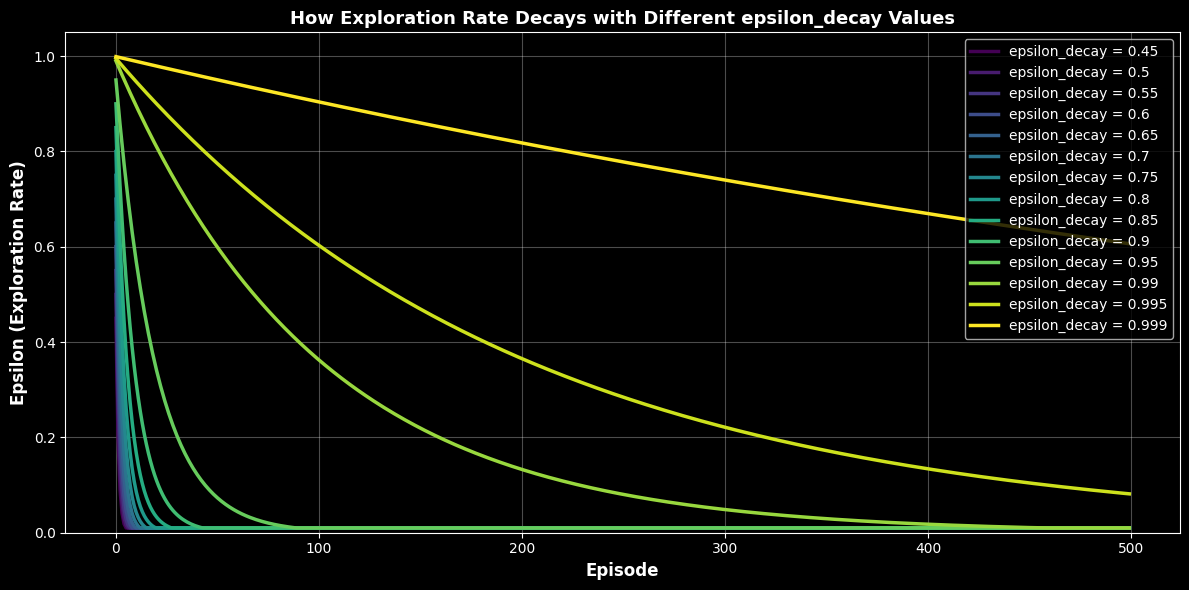

In [7]:
# ======== Plot mean epsilon decay paths across seeds ========
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(epsilon_decay_values)))

for idx, eps_decay in enumerate(epsilon_decay_values):
    epsilon_history = results[eps_decay]['epsilon_history']
    ax.plot(epsilon_history, linewidth=2.5, label=f'epsilon_decay = {eps_decay}', color=colors[idx])

ax.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax.set_ylabel('Epsilon (Exploration Rate)', fontsize=12, fontweight='bold')
ax.set_title('How Exploration Rate Decays with Different epsilon_decay Values', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()
# ======== End plot mean epsilon decay paths across seeds ========


**Exploration Rate Decay**

Where y = 0 represents pure exploitation and y = 1 represents pure exploration, this graph shows how different epsilon decay values control the exploration-exploitation transition.

Almost all epsilon_decay values drop steeply in the first 100 episodes, transitioning from full exploration (y=1.0) toward exploitation. The critical difference lies in what happens after episode 100:

Low epsilon decay (0.45–0.95 - dark purple/green lines): Reach near-zero exploration by episode ~100 and stay there. The agent commits to exploitation early and never explores again.

Medium epsilon decay (0.99 - light green): Continue dropping gradually after episode 100, reaching near-zero by episode ~400. This provides a longer exploitation-learning window before committing fully.

High epsilon decay (0.995-0.999 - yellow line): Drop much more slowly after episode 100, maintaining 10-30% exploration even at episode 500. The agent keeps a "safety margin" of exploration throughout.


## 8. Visualization: Overlaid Reward Curves

In [1]:
final_epsilon_decay_values = [0.75, 0.80, 0.90, 0.95, 0.99, 0.995]


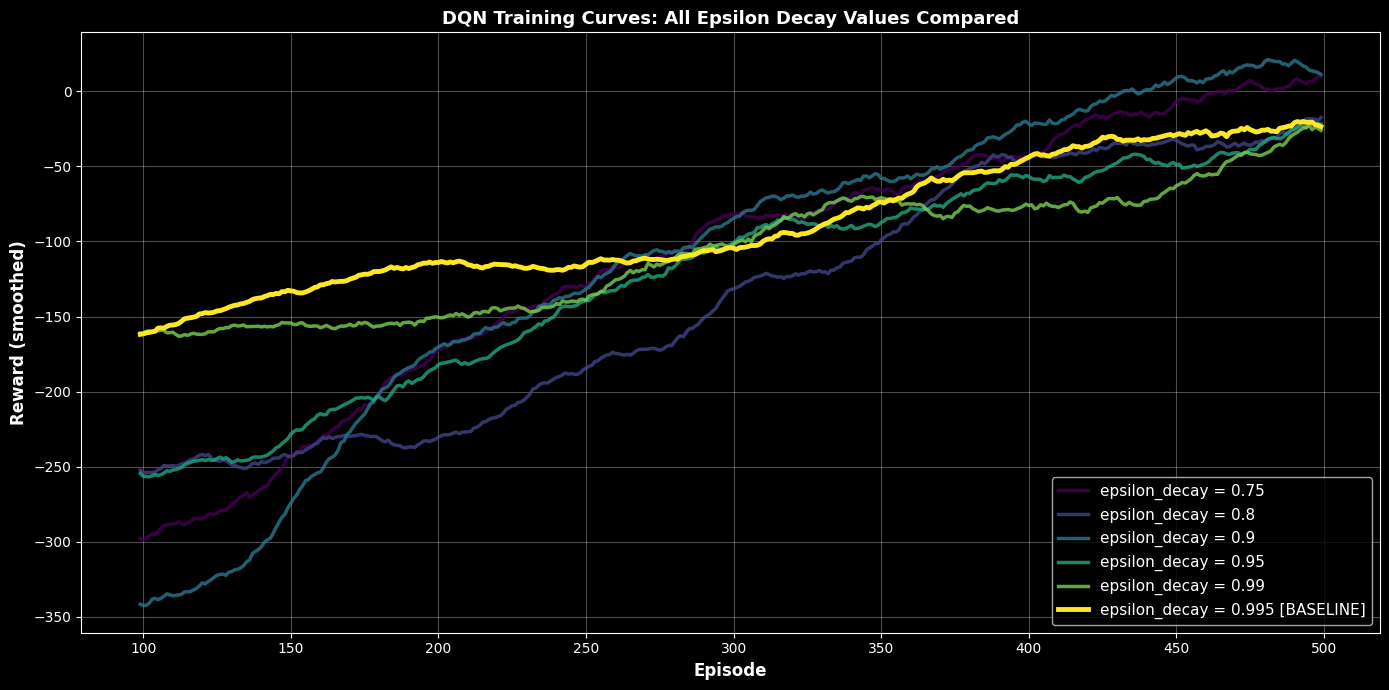

In [22]:
import pickle, os
import numpy as np
import matplotlib.pyplot as plt

class RestrictedUnpickler(pickle.Unpickler):
    SAFE_MODULES = {'numpy', 'numpy.core.multiarray', 'numpy.core', '_codecs', 'builtins', 'collections'}
    def find_class(self, module, name):
        if any(module.startswith(m) for m in self.SAFE_MODULES):
            return super().find_class(module, name)
        class Placeholder:
            def __init__(self, *a, **kw): pass
            def __setstate__(self, state): self.__dict__.update(state) if isinstance(state, dict) else None
        return Placeholder

BASE = r'D:\2026-1\Deep Learning\finalProject\Project\GitHubProject\COMP3242-Group-Project-DQN\results\ablations\epsilon_decay'
final_epsilon_decay_values = [0.75, 0.80, 0.90, 0.95, 0.99, 0.995]
seeds = [0, 1, 2, 3, 4]

results = {}
for eps_decay in final_epsilon_decay_values:
    seed_rewards = []
    for seed in seeds:
        path = os.path.join(BASE, f'{eps_decay}_seed_{seed}', 'results.pkl')
        with open(path, 'rb') as f:
            d = RestrictedUnpickler(f).load()
        seed_rewards.append(d['episode_rewards'])
    results[eps_decay] = {'rewards': np.mean(seed_rewards, axis=0)}

fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.viridis(np.linspace(0, 1, len(final_epsilon_decay_values)))

for idx, eps_decay in enumerate(final_epsilon_decay_values):
    rewards = results[eps_decay]['rewards']
    window = 100
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
    linewidth = 3.5 if eps_decay == 0.995 else 2.5
    alpha = 1.0 if eps_decay == 0.995 else 0.8
    ax.plot(range(window-1, len(rewards)), smoothed, linewidth=linewidth,
            label=f'epsilon_decay = {eps_decay}' + (' [BASELINE]' if eps_decay == 0.995 else ''),
            color=colors[idx], alpha=alpha)

ax.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax.set_ylabel('Reward (smoothed)', fontsize=12, fontweight='bold')
ax.set_title('DQN Training Curves: All Epsilon Decay Values Compared', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The previous graph shows the smoothed training curves
(window $= 50$) for the six best-performing epsilon decay
values. The baseline ($\epsilon_{\text{decay}} = 0.995$,
yellow) exhibits the most stable learning trajectory,
maintaining a consistent upward trend throughout training.
$\epsilon_{\text{decay}} = 0.90$ shows continuous improvement
across all 500 episodes, ultimately achieving the highest
rewards in the final episodes despite not ranking among the
top three in overall average reward. This is consistent with
a slower but more sustained learning process.

Values 0.99 and 0.995 follow a similar trajectory to the
baseline, while 0.75 and 0.80 exhibit a characteristic
pattern: poor initial performance followed by rapid
improvement in later episodes. This behaviour is typical
in LunarLander-v3, where the agent initially crashes
frequently but eventually discovers a stable landing
strategy. The high initial variance for these fast-decay
configurations suggests that their early greedy behaviour
forces the agent through a longer period of suboptimal
crashes before converging.

All six curves show positive slopes at episode 500,
confirming that none had fully converged, and that
extended training would likely further separate the
configurations.

# Summary

Loaded 0.75 (5 seeds)
Loaded 0.8 (5 seeds)
Loaded 0.9 (5 seeds)
Loaded 0.95 (5 seeds)
Loaded 0.99 (5 seeds)
Loaded 0.995 (5 seeds)


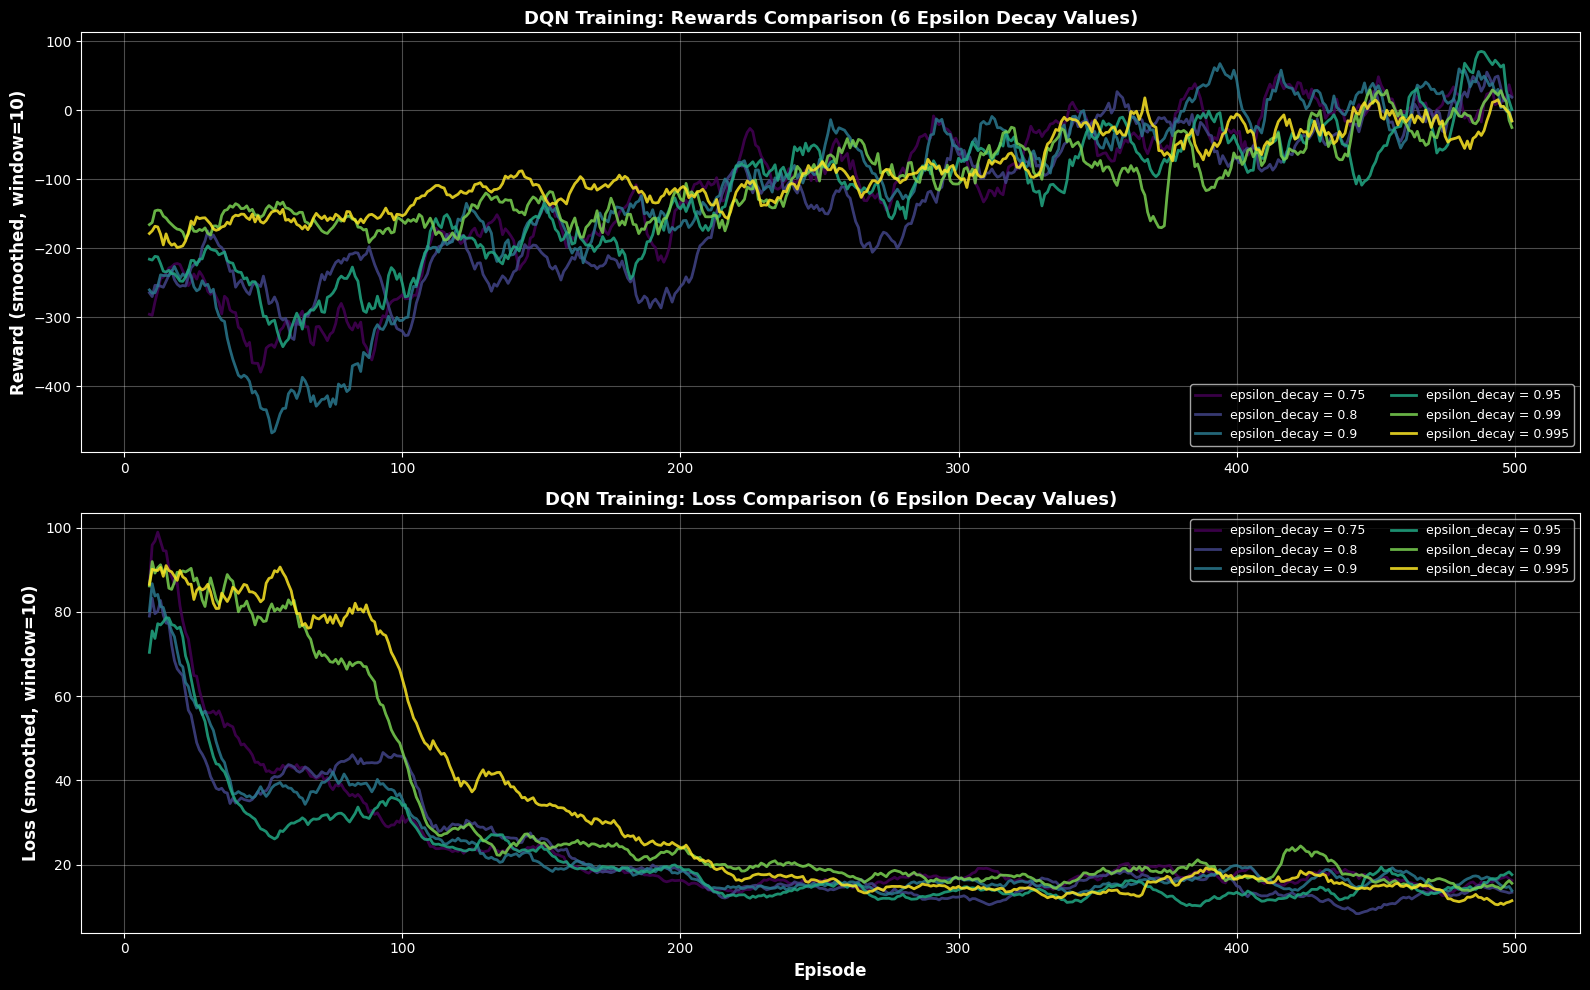

In [23]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

class RestrictedUnpickler(pickle.Unpickler):
    SAFE_MODULES = {'numpy', 'numpy.core.multiarray', 'numpy.core', '_codecs', 'builtins', 'collections'}
    def find_class(self, module, name):
        if any(module.startswith(m) for m in self.SAFE_MODULES):
            return super().find_class(module, name)
        class Placeholder:
            def __init__(self, *a, **kw): pass
            def __setstate__(self, state): self.__dict__.update(state) if isinstance(state, dict) else None
        return Placeholder

BASE = r'D:\2026-1\Deep Learning\finalProject\Project\GitHubProject\COMP3242-Group-Project-DQN\results\ablations\epsilon_decay'
epsilon_decay_values =  [0.75, 0.80, 0.90, 0.95, 0.99, 0.995]
seeds = [0, 1, 2, 3, 4]

# Load and average across seeds
results = {}
for eps_decay in epsilon_decay_values:
    seed_rewards, seed_losses = [], []
    for seed in seeds:
        path = os.path.join(BASE, f'{eps_decay}_seed_{seed}', 'results.pkl')
        if not os.path.exists(path):
            print(f"  Missing: {eps_decay}_seed_{seed}")
            continue
        with open(path, 'rb') as f:
            d = RestrictedUnpickler(f).load()
        seed_rewards.append(d['episode_rewards'])
        seed_losses.append(d['episode_losses'])
    if seed_rewards:
        results[eps_decay] = {
            'rewards': np.mean(seed_rewards, axis=0),
            'losses':  np.mean(seed_losses,  axis=0),
        }
        print(f"Loaded {eps_decay} ({len(seed_rewards)} seeds)")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(results)))
window = 10

for idx, eps_decay in enumerate(epsilon_decay_values):
    if eps_decay not in results:
        continue
    rewards = results[eps_decay]['rewards']
    losses  = results[eps_decay]['losses']

    smoothed_rewards = np.convolve(rewards, np.ones(window)/window, mode='valid')
    smoothed_losses  = np.convolve(losses,  np.ones(window)/window, mode='valid')
    episodes = range(window-1, len(rewards))

    ax1.plot(episodes, smoothed_rewards, linewidth=2,
             label=f'epsilon_decay = {eps_decay}', color=colors[idx], alpha=0.85)
    ax2.plot(episodes, smoothed_losses, linewidth=2,
             label=f'epsilon_decay = {eps_decay}', color=colors[idx], alpha=0.85)

ax1.set_ylabel('Reward (smoothed, window=10)', fontsize=12, fontweight='bold')
ax1.set_title('DQN Training: Rewards Comparison (6 Epsilon Decay Values)', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax2.set_ylabel('Loss (smoothed, window=10)', fontsize=12, fontweight='bold')
ax2.set_title('DQN Training: Loss Comparison (6 Epsilon Decay Values)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9, ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'D:\2026-1\Deep Learning\finalProject\Project\GitHubProject\COMP3242-Group-Project-DQN\results\ablations\epsilon_decay\comparison_14values_rewards_losses.png', dpi=300)
plt.show()

The loss curves (right panel) show that all configurations
stabilise by approximately episode 200, with
$\epsilon_{\text{decay}} = 0.995$ taking longest to
converge due to continued exploration disturbing the
Q-value estimates. Once stabilised, all loss curves
converge to a similar level, suggesting the differences
in reward performance are driven by policy quality rather
than optimisation instability.

Overall, we can observe that the most stable training curves across all episodes correspond to configurations where epsilon decays gradually throughout training. However,the configurations that achieve the highest final rewards (0.75 and 0.90) are those with faster decay, reaching
near-zero exploration by episodes 0-100, meaning the agent became fully greedy very early in training. While this may appear beneficial at first glance, it is important to note that this is not necessarily a good exploration strategy. When epsilon reaches zero prematurely, the agent stops exploring entirely for the remaining 400+ episodes, locking itself into whatever policy it managed to learn in the first 100 episodes. The strong late-episode performance of these configurations (0.9 and 0.75) is therefore somewhat coincidental, their early random exploration happened to be sufficient to bootstrap a reasonable policy, but this is not reliable for shorter episodes.


A well-designed exploration schedule should reach near-zero epsilon toward the end of training, not the beginning, so that the agent explores broadly early and gradually commits to its learned policy. The baseline (ε-decay = 0.995) follows this principle more correctly, maintaining meaningful exploration throughout the 500-episode budget. If training were extended beyond 500 episodes, the gradual-decay configurations would likely continue to improve steadily, while the fast-decay variants, having already exhausted their exploration, would plateau or stagnate.
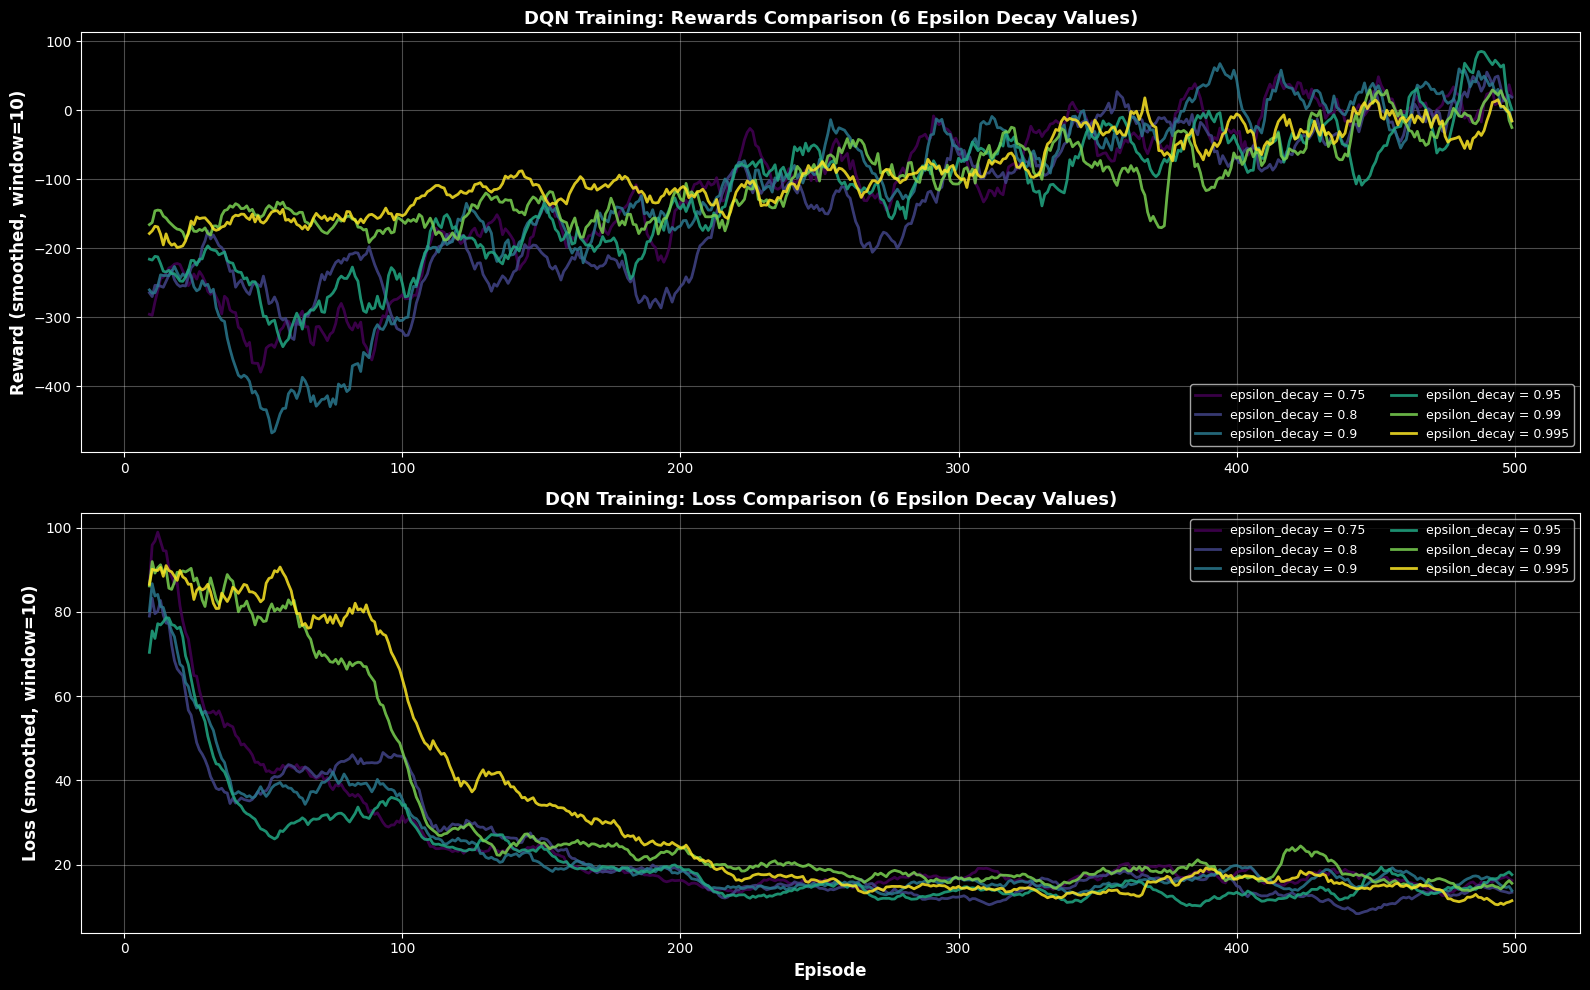